**R0**

Columnas detectadas: ['Run', 'X', 'Y']
------------------------------
Resultados guardados en: C:\Users\Usuario\Desktop\Beale\Beale_R0_act.csv
------------------------------
   Run     X        Y            R0
0    1  0.64 -0.52000  7.034192e+00
1    2 -2.72 -4.00000  1.687959e+06
2    3  0.64 -4.00000  2.883440e+02
3    4  4.00  3.00000  3.001559e+06
4    5  1.20  2.31926  6.150510e+02


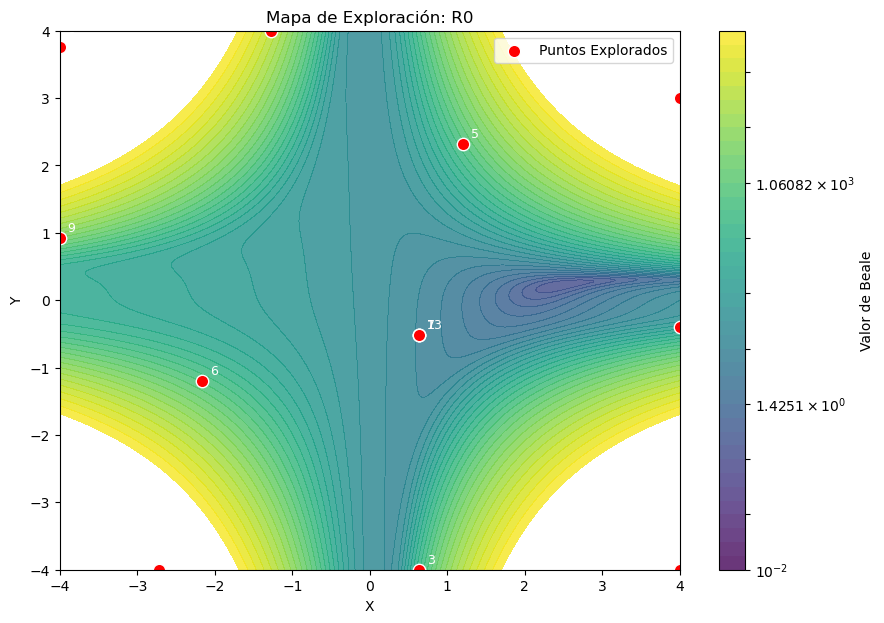

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Definimos la ruta de entrada
input_file = r"C:\Users\Usuario\Desktop\Beale\Beale_R0.csv"
# Definimos la ruta de salida (en la misma carpeta)
output_file = r"C:\Users\Usuario\Desktop\Beale\Beale_R0_act.csv"
output_plot = r"C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg"

# Usamos 'r' al principio de la ruta para que Windows no confunda las \ con comandos

    
try:

    # 1. Cargar datos # Leemos el archivo detectando automáticamente el separador (coma o punto y coma)
    df = pd.read_csv(input_file, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")


    # 2. Definir la función de Rosenbrock
    def beale(x, y):
        return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)

    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    # 4. Calcular el resultado y guardarlo en la nueva columna 4 (indice 3)
    df['R0'] = beale(val_x, val_y)

    # 5. Guardar el archivo actualizado en el Escritorio
    df.to_csv(output_file, index=False)

    print("-" * 30)
    print(f"Resultados guardados en: {output_file}")
    print("-" * 30)
    print(df.head()) # Mostrar los primeros resultados para verificar

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {input_file}")
except Exception as e: 
    print(f"Ocurrió un error: {e}")



# 1. Crear el fondo de la función
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)


# 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(vmin=0.01, vmax=10**5), cmap='viridis', alpha=0.8)
plt.colorbar(label='Valor de Beale')

# 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

plt.title("Mapa de Exploración: R0")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado correctamente com :{output_plot}")

**R1**

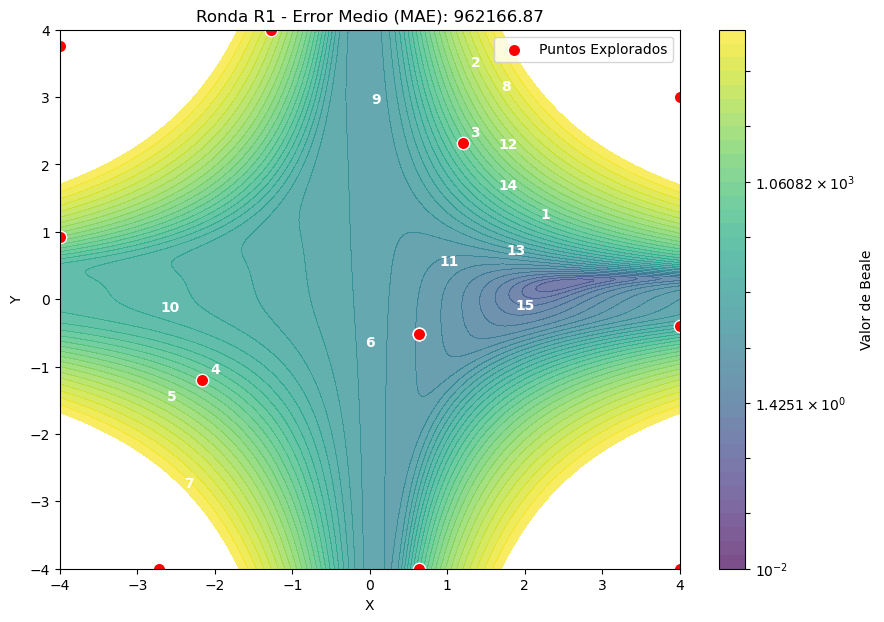

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R1.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R1 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R2**

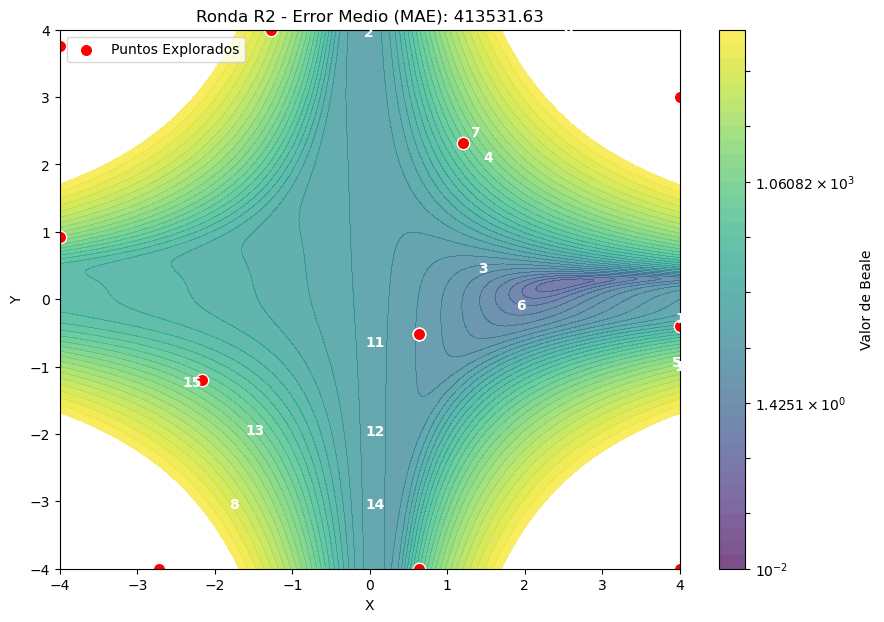

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R2.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R2 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R3**

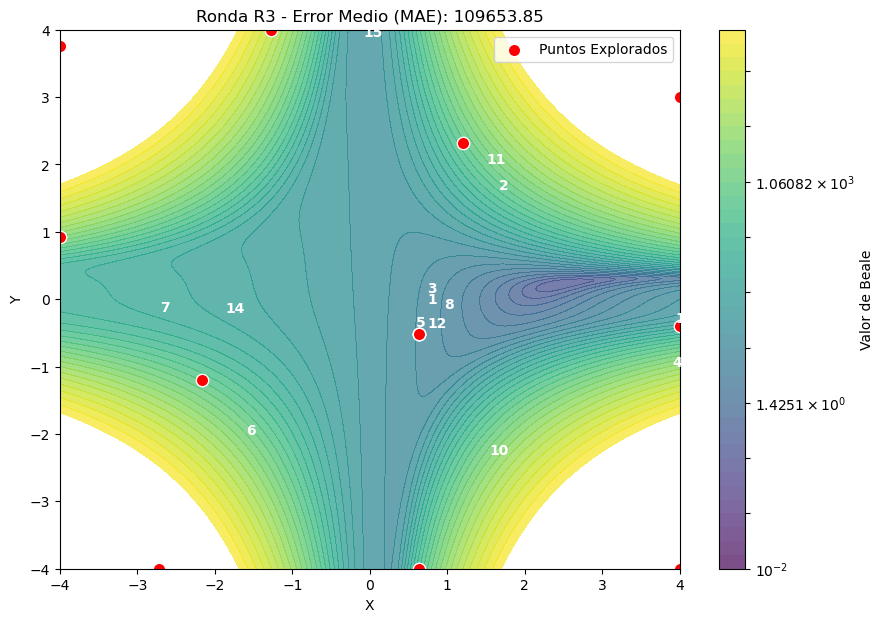

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R3.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R3 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R4**

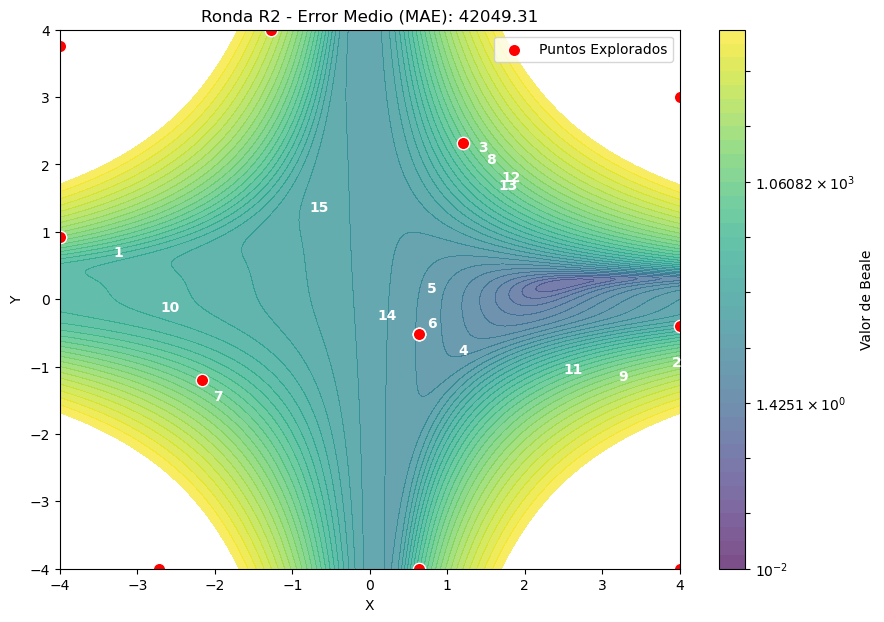

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R4.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R4 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R5**

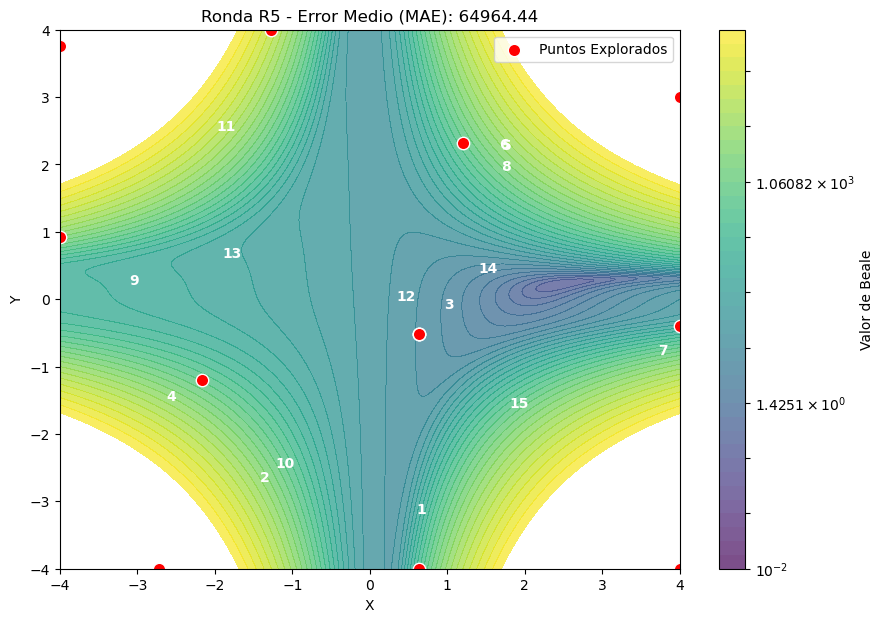

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R5.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R5 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R6**

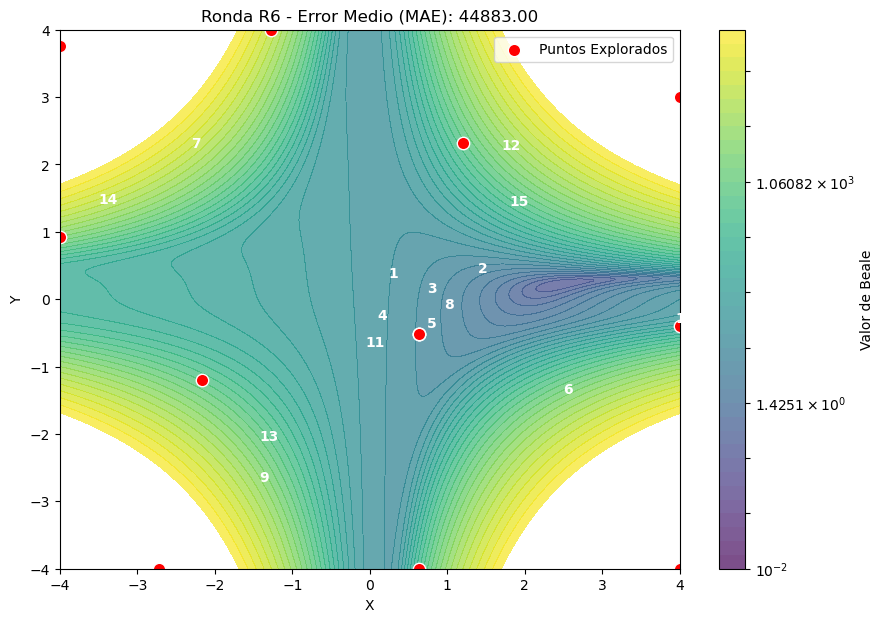

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R6.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R6 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R7**

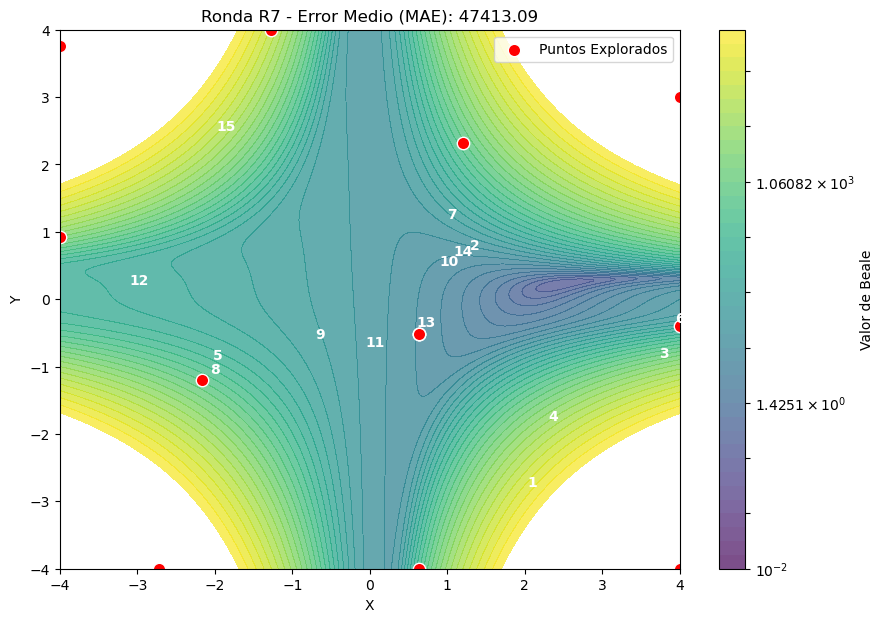

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R7.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R7 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")



**R8**

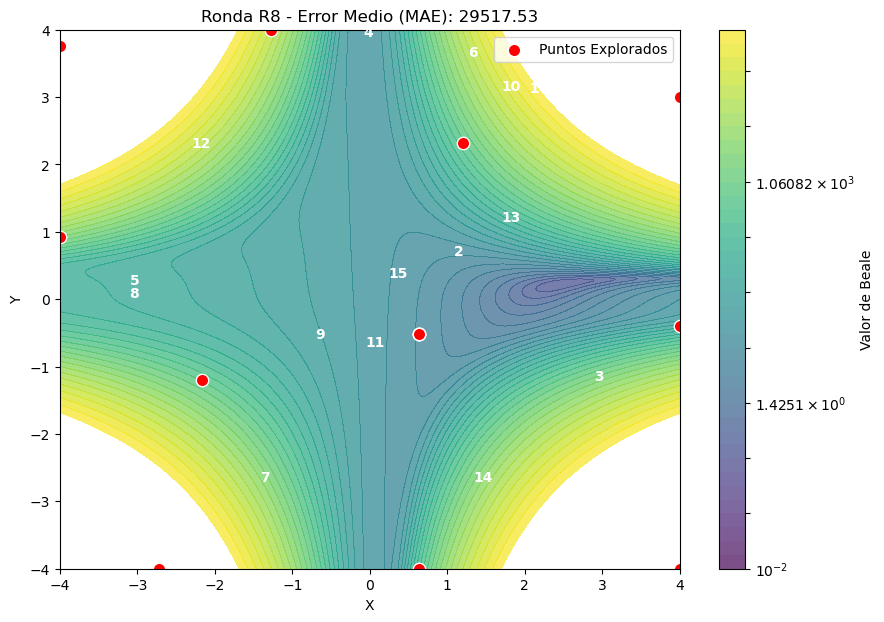

Gráfico guardado correctamente com :C:\Users\Usuario\Desktop\Beale\Beale_R0_plot.jpg


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. CARGAR DATOS (Cambia solo el nombre del archivo si es necesario)
file_path = r"C:\Users\Usuario\Desktop\Beale\Beale_R8.csv"
df = pd.read_csv(file_path, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. DEFINIR FUNCIÓN Y MÍNIMOS
def beale(x, y):
    return ((1.5 - x + (x*y))**2 + (2.25 - x +(x*y)**2)**2 + (2.625 - x + (x*y)**3)**2)
        
min_x, min_y = (3, 0.5)

# 3. CÁLCULOS (X e Y son columnas 2 y 3; R1 es la columna 4)
x, y, r1_propuesto = df.iloc[:, 1], df.iloc[:, 2], df.iloc[:, 3]

df['Real'] = beale(x, y)
df['MAE'] = np.abs(df['Real'] - r1_propuesto)

# Distancias al mínimo 
df['Dist_Minimo'] = np.sqrt((x - min_x)**2 + (y - min_y)**2)

# 4. FILA DE RESUMEN (Final del archivo)
# Calculamos los valores antes de concatenar para evitar errores de tipo
resumen_dict = {
    df.columns[0]: 'RESUMEN', 
    'Real': df['Real'].min(), 
    'MAE': df['MAE'].mean(),
    'Dist_Minimo': df['Dist_Minimo'].min()
}
resumen = pd.Series(resumen_dict)
df = pd.concat([df, resumen.to_frame().T], ignore_index=True)

# 5. GUARDAR
df.to_csv(file_path.replace(".csv", "_RESULTADO.csv"), index=False)

# 6. GRÁFICO 
## 1. Crear el fondo de la función 
x_range = np.linspace(-4, 4, 400)
y_range = np.linspace(-4, 4, 400)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
Z_mesh = ((1.5 - X_mesh + (X_mesh*Y_mesh))**2 + (2.25 - X_mesh +(X_mesh*Y_mesh)**2)**2 + (2.625 - X_mesh + (X_mesh*Y_mesh)**3)**2)

## 2. Dibujar el mapa
plt.figure(figsize=(10, 7))
plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(-2, 5, 40), norm=LogNorm(), cmap='viridis', alpha=0.7)
plt.colorbar(label='Valor de Beale')



# 3. Dibujar TUS puntos (quitando la fila de resumen para el gráfico)
puntos = df.iloc[:-1] 
plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Puntos Explorados')

# Añadir etiquetas de número de RUN
for i, row in df.iterrows():
# Usamos try/except por si acaso hay algún valor extraño, pero con 'puntos' ya debería funcionar
    try:
        x_val = row.iloc[1]
        y_val = row.iloc[2]
        run_num = int(row.iloc[0]) # Ahora sí puede convertir a entero
        plt.text(x_val + 0.1, y_val + 0.1, str(run_num), color='white', fontsize=10, fontweight='bold')
    except:
        pass
        
plot_path = file_path.replace(".csv", "_Grafico.jpg")
plt.title(f"Ronda R8 - Error Medio (MAE): {resumen['MAE']:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado correctamente com :{output_plot}")

